# 01 — Exploratory Data Analysis

**Owner:** Ian Schmitt (T3) · **Reads:** `data/processed/splits.parquet` · **Writes:** `outputs/figures/01-eda_*.png`, `outputs/tables/01-eda_*.csv`

This notebook characterizes the corpus before any modeling: split and class balance, review-length distributions, markup artifacts, and the n-gram vocabulary by class. Everything here is **descriptive** — it motivates preprocessing and metric choices already recorded in `docs/decisions.md`; it fits no models and reads no feature artifacts.

**Scope policy:** the split/class count table covers all three splits (bookkeeping), but every *content* analysis — lengths, artifacts, n-grams — uses the **fit split only** (10,000 reviews). No test-split text is examined before notebooks 04/05, in spirit as well as letter.

In [1]:
# Shared foundation from src/shared.py (landed with 00_core).
import pathlib
import sys

sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
from shared import PATHS, PLOT_STYLE, load_splits, preprocess_text

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter
from sklearn.feature_extraction.text import CountVectorizer

plt.rcParams.update(PLOT_STYLE)  # shared base style
plt.rcParams.update(  # EDA-local additions, deliberately not in shared.py
    {
        "figure.dpi": 100,
        "savefig.dpi": 150,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
FIG, TBL = PATHS["figures_dir"], PATHS["tables_dir"]
CLASS_NAMES = {0: "negative", 1: "positive"}
COLORS = {"negative": "indianred", "positive": "steelblue"}

In [3]:
# shared.load_splits raises a clear error if 00_core has not been run here.
splits = load_splits()
print("rows:", len(splits))
splits.head(3)

rows: 40000


,id,text,label,split
0,0,I rented I AM CURIOUS-YELLOW from my video sto...,0,fit
1,2,If only to avoid making this type of film in t...,0,val
2,3,This film was probably inspired by Godard's Ma...,0,fit


## Corpus shape and class balance

Counts per split and class establish the project's scope and the **baseline to beat**: the accuracy a model gets by always predicting the most common class. IMDB is constructed 50/50, so if the splits preserved that balance the floor is 50% — which is what makes plain accuracy a usable headline metric for this comparison (with precision/recall/F1/ROC-AUC computed alongside in notebook 04).

In [4]:
counts = (
    splits.groupby(["split", "label"])
    .size()
    .unstack()
    .rename(columns=CLASS_NAMES)
    .loc[["fit", "val", "test"]]
)
counts["total"] = counts.sum(axis=1)
counts.to_csv(TBL / "01-eda_split_balance.csv")

majority = counts[["negative", "positive"]].max(axis=1) / counts["total"]
print("Majority-class baseline accuracy per split:")
print(majority.map("{:.1%}".format).to_string())
counts

Majority-class baseline accuracy per split:
split
fit     50.0%
val     50.0%
test    50.0%


label,negative,positive,total
split,,,
fit,5000,5000,10000
val,2500,2500,5000
test,12500,12500,25000


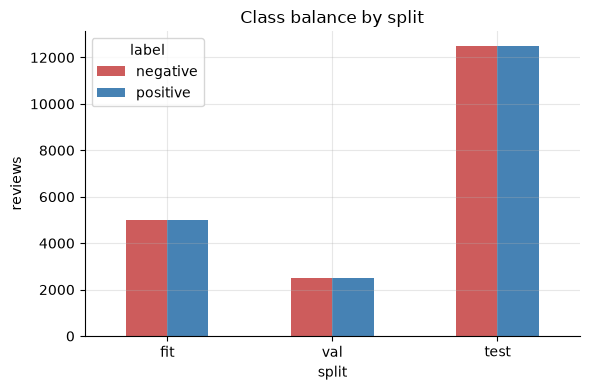

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
counts[["negative", "positive"]].plot.bar(
    ax=ax, color=[COLORS["negative"], COLORS["positive"]]
)
ax.set_ylabel("reviews")
ax.set_xlabel("split")
ax.set_title("Class balance by split")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIG / "01-eda_split_balance.png")

## Review length by class

Words per review (simple whitespace tokens — interpretable and tokenizer-free). Two things matter downstream: the **long tail** motivates capping the TF-IDF vocabulary (`max_features ≈ 20k`) rather than keeping every rare term, and any length *difference between classes* would be a shortcut feature the models could lean on. From here on, all content analysis uses the fit split only.

In [6]:
fit = splits[splits["split"] == "fit"].copy()
fit["n_words"] = fit["text"].str.split().str.len()

length_summary = (
    fit.groupby(fit["label"].map(CLASS_NAMES))["n_words"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95])
    .round(1)
    .rename_axis("class")
)
length_summary.to_csv(TBL / "01-eda_length_summary.csv")
length_summary

,count,mean,std,min,25%,50%,75%,95%,max
class,,,,,,,,,
negative,5000.0,230.4,164.1,10.0,129.0,176.0,277.0,573.1,1364.0
positive,5000.0,234.0,179.6,12.0,124.0,171.0,287.0,617.0,2470.0


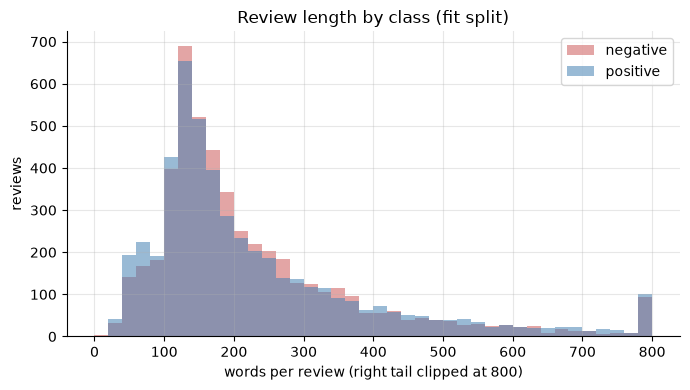

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.arange(0, 820, 20)
for label, name in CLASS_NAMES.items():
    vals = fit.loc[fit["label"] == label, "n_words"].clip(upper=800)
    ax.hist(vals, bins=bins, alpha=0.55, color=COLORS[name], label=name)
ax.set_xlabel("words per review (right tail clipped at 800)")
ax.set_ylabel("reviews")
ax.set_title("Review length by class (fit split)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "01-eda_length_by_class.png")

## Markup artifacts

IMDB reviews were scraped from the web, and line breaks survive as literal `<br />` tags. This is the classic annotation-artifact problem: untreated, the tokenizer happily turns markup into a *feature*. First the prevalence sweep, then the demonstration — the top-20 unigrams with and without stripping — which is the empirical justification for the `strip <br />` rule frozen in `docs/decisions.md`.

In [8]:
patterns = {
    "<br /> line break": r"<br\s*/?>",
    "any <tag>": r"<[a-zA-Z][^>]*>",
    "HTML entity (&...;)": r"&[a-z]+;",
    "non-ASCII characters": r"[^\x00-\x7F]",
}
artifacts = pd.DataFrame(
    {
        "reviews_containing": {
            name: int(fit["text"].str.contains(pat, regex=True).sum())
            for name, pat in patterns.items()
        }
    }
)
artifacts["pct_of_fit"] = (artifacts["reviews_containing"] / len(fit) * 100).round(1)
artifacts.to_csv(TBL / "01-eda_html_artifacts.csv")
artifacts

,reviews_containing,pct_of_fit
<br /> line break,5816,58.2
any <tag>,5817,58.2
HTML entity (&...;),0,0.0
non-ASCII characters,946,9.5


'br' rank among raw unigrams: 6 (39,908 occurrences)


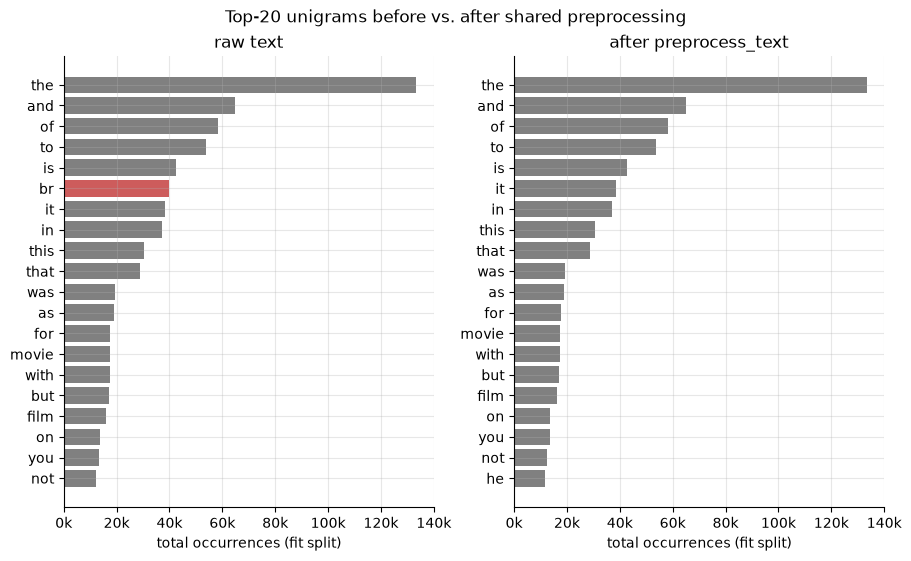

In [9]:
def top_unigrams(texts, k=20):
    cv = CountVectorizer(lowercase=True)
    x = cv.fit_transform(texts)
    totals = np.asarray(x.sum(axis=0)).ravel()
    vocab = np.array(cv.get_feature_names_out())
    order = np.argsort(totals)[::-1][:k]
    return pd.Series(totals[order], index=vocab[order])


raw_top = top_unigrams(fit["text"])
stripped_top = top_unigrams(fit["text"].map(preprocess_text))

fig, axes = plt.subplots(1, 2, figsize=(9, 5.5), sharex=True, layout="constrained")
panels = [
    (axes[0], raw_top, "raw text"),
    (axes[1], stripped_top, "after preprocess_text"),
]
for ax, top, title in panels:
    colors = ["indianred" if w == "br" else "grey" for w in top.index]
    ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
    ax.set_title(title)
    ax.set_xlabel("total occurrences (fit split)")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v / 1000:.0f}k"))
fig.suptitle("Top-20 unigrams before vs. after shared preprocessing")
fig.savefig(FIG / "01-eda_br_artifact_demo.png")

rank = int(np.where(raw_top.index == "br")[0][0]) + 1 if "br" in raw_top.index else None
print(f"'br' rank among raw unigrams: {rank} ({raw_top.get('br', 0):,} occurrences)")

## Top n-grams by class

Raw counts (`CountVectorizer`, not the TF-IDF artifact — this notebook reads no feature artifacts) on stripped, lowercased text with stop words kept, matching the shared preprocessing choices. Two views:

1. **Most frequent** unigrams and bigrams per class — the required item. Expect heavy overlap: both classes talk about films in the same function words.
2. **Most distinctive** n-grams per class via a smoothed log-ratio of class frequencies — this is the view that previews the sentiment lexicon, i.e., the words logistic regression's coefficients should later recover in notebook 02.

In [10]:
fit["clean"] = fit["text"].map(preprocess_text)
NGRAM_TYPE = {1: "unigram", 2: "bigram"}


def top_ngrams_by_class(n, k=20):
    cv = CountVectorizer(lowercase=True, ngram_range=(n, n), min_df=2)
    x = cv.fit_transform(fit["clean"])
    vocab = np.array(cv.get_feature_names_out())
    rows = []
    for label, name in CLASS_NAMES.items():
        mask = (fit["label"] == label).to_numpy()
        totals = np.asarray(x[mask].sum(axis=0)).ravel()
        order = np.argsort(totals)[::-1][:k]
        rows += [
            {
                "class": name,
                "ngram_type": NGRAM_TYPE[n],
                "rank": r + 1,
                "ngram": vocab[i],
                "count": int(totals[i]),
            }
            for r, i in enumerate(order)
        ]
    return pd.DataFrame(rows)


top_ngrams = pd.concat(
    [top_ngrams_by_class(1), top_ngrams_by_class(2)], ignore_index=True
)
top_ngrams.to_csv(TBL / "01-eda_top_ngrams_by_class.csv", index=False)

preview = top_ngrams[top_ngrams["rank"] <= 10].assign(
    item=lambda d: d["ngram"] + "  (" + d["count"].astype(str) + ")"
)
preview.pivot(index="rank", columns=["ngram_type", "class"], values="item")

ngram_type        unigram                             bigram  \
class            negative       positive            negative   
rank                                                           
1            the  (64736)   the  (68658)      of the  (7094)   
2            and  (29725)   and  (35225)      in the  (4906)   
3             of  (27605)    of  (30582)  this movie  (3532)   
4             to  (27538)    to  (26267)       to be  (2772)   
5             is  (19756)    is  (22878)   the movie  (2662)   
6             it  (19403)    in  (19766)    the film  (2596)   
7             in  (17362)    it  (19067)     and the  (2391)   
8           this  (16438)  this  (14013)   this film  (2252)   
9           that  (14970)  that  (13866)      to the  (2150)   
10           was  (10867)    as  (10574)      it was  (1895)   

ngram_type                      
class                 positive  
rank                            
1               of the  (8525)  
2               in the  (5132)  
3              and the  (2870)  
4             the film  (2819)  
5           this movie  (2632)  
6               to the  (2562)  
7                it is  (2444)  
8              this is  (2172)  
9            this film  (2097)  
10           the movie  (2063)

vocabulary size (uni+bigrams, min_df=2): 210,003 types


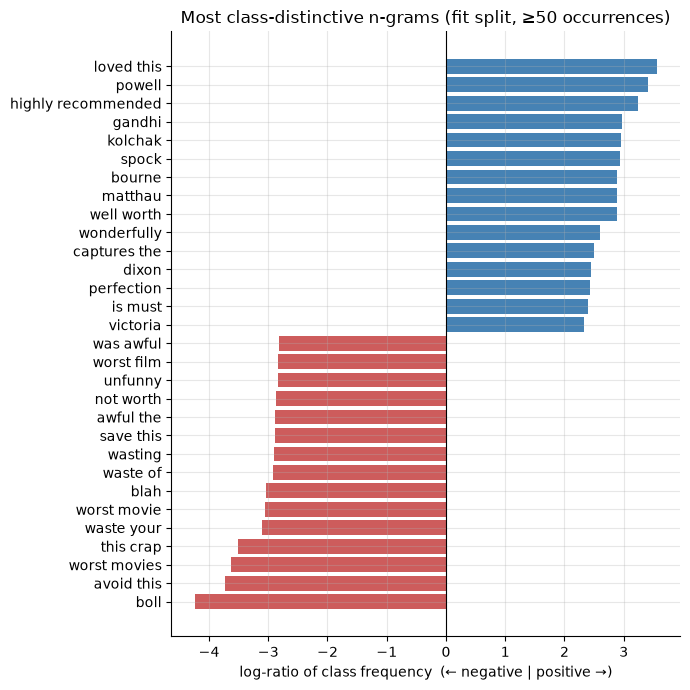

In [11]:
cv = CountVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2)
x = cv.fit_transform(fit["clean"])
vocab = np.array(cv.get_feature_names_out())
print(f"vocabulary size (uni+bigrams, min_df=2): {len(vocab):,} types")
neg_mask = (fit["label"] == 0).to_numpy()
neg = np.asarray(x[neg_mask].sum(axis=0)).ravel()
pos = np.asarray(x[~neg_mask].sum(axis=0)).ravel()

# Smoothed log-ratio of relative class frequencies (add-1). A frequency floor
# keeps rare n-grams from dominating the ranking on unstable ratios.
log_ratio = np.log((pos + 1) / (pos.sum() + len(vocab))) - np.log(
    (neg + 1) / (neg.sum() + len(vocab))
)
frequent = np.where(neg + pos >= 50)[0]
order = frequent[np.argsort(log_ratio[frequent])]
sel = np.concatenate([order[:15], order[-15:]])

fig, ax = plt.subplots(figsize=(7, 7))
vals = log_ratio[sel]
colors = [COLORS["negative"] if v < 0 else COLORS["positive"] for v in vals]
ax.barh(vocab[sel], vals, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("log-ratio of class frequency  (\u2190 negative | positive \u2192)")
ax.set_title("Most class-distinctive n-grams (fit split, \u226550 occurrences)")
fig.tight_layout()
fig.savefig(FIG / "01-eda_distinctive_ngrams.png")

## Data-quality notes

Report-only checks on the fit split: exact-duplicate review texts and near-empty reviews. No action is taken here — the split spec is frozen in `docs/decisions.md`, so anything nonzero becomes a documented limitation rather than a silent data mutation.

In [12]:
dup_counts = fit["text"].value_counts()
dup_texts = dup_counts[dup_counts > 1]
dup_rows = int(dup_texts.sum() - len(dup_texts))
conflicting = int(
    fit[fit["text"].isin(dup_texts.index)]
    .groupby("text")["label"]
    .nunique()
    .gt(1)
    .sum()
)
near_empty = int((fit["n_words"] < 5).sum())

print(f"exact-duplicate texts: {len(dup_texts)} distinct texts appear more than once")
print(f"  -> {dup_rows} redundant rows; {conflicting} duplicated with BOTH labels")
print(f"reviews under 5 words: {near_empty}")

exact-duplicate texts: 17 distinct texts appear more than once
  -> 18 redundant rows; 0 duplicated with BOTH labels
reviews under 5 words: 0


## Key takeaways

- **Balance:** every split is exactly 50/50, so the majority-class floor is 50% and plain accuracy is a legitimate headline metric for the model comparison (the full metric suite still lands in notebook 04).
- **Length is not a shortcut feature:** the class distributions overlap almost completely (median 176 words negative vs. 171 positive). The long right tail (95th percentile ~570-620 words, max 2,470) is part of why the shared TF-IDF vocabulary is capped at ~20k features rather than keeping every rare term.
- **Markup:** 58% of fit reviews contain `<br />`, and untreated it lands as the **#6 unigram overall (~40k occurrences)** - the annotation-artifact problem in one bar chart. Stripping it is essentially the whole cleaning job: exactly one review contains any other HTML tag, and HTML entities are absent.
- **Lexicon preview - and entity leakage:** the class-distinctive n-grams are of two kinds. Genuine sentiment vocabulary ("loved this", "highly recommended", "well worth" vs. "waste of", "avoid this", "worst movie") previews what LR's coefficients should recover in notebook 02. But proper nouns rank just as high (Powell, Gandhi, Spock, Matthau on the positive side; "boll" - the director Uwe Boll - is the single most negative-distinctive term). Bag-of-words models will learn *entity priors* alongside sentiment: a lens for reading LR's coefficients, a candidate explanation for model disagreements (notebook 05's `other` tag), and a real limitation for the recommender framing, since entity priors do not transfer beyond this corpus.
- **Data quality:** 17 duplicated review texts (18 redundant rows, none with conflicting labels) and zero near-empty reviews. Reported as a limitation; the frozen split spec is not mutated.

In [13]:
# Handoff manifest: every artifact this notebook wrote, for the record.
written = sorted(
    p.relative_to(PATHS["repo_root"])
    for p in list(FIG.glob("01-eda_*.png")) + list(TBL.glob("01-eda_*.csv"))
)
print(f"{len(written)} artifacts written:")
for p in written:
    print(" ", p)

8 artifacts written:
  outputs/figures/01-eda_br_artifact_demo.png
  outputs/figures/01-eda_distinctive_ngrams.png
  outputs/figures/01-eda_length_by_class.png
  outputs/figures/01-eda_split_balance.png
  outputs/tables/01-eda_html_artifacts.csv
  outputs/tables/01-eda_length_summary.csv
  outputs/tables/01-eda_split_balance.csv
  outputs/tables/01-eda_top_ngrams_by_class.csv
